# Logistic curve fitting

The goal of this project is to evaluate fitting procedures to fit logistic curves with incomplete data. The problem is that when there only is data to the left of the inflection point, logistic fits tend to get extremly senitive to measurement errors.

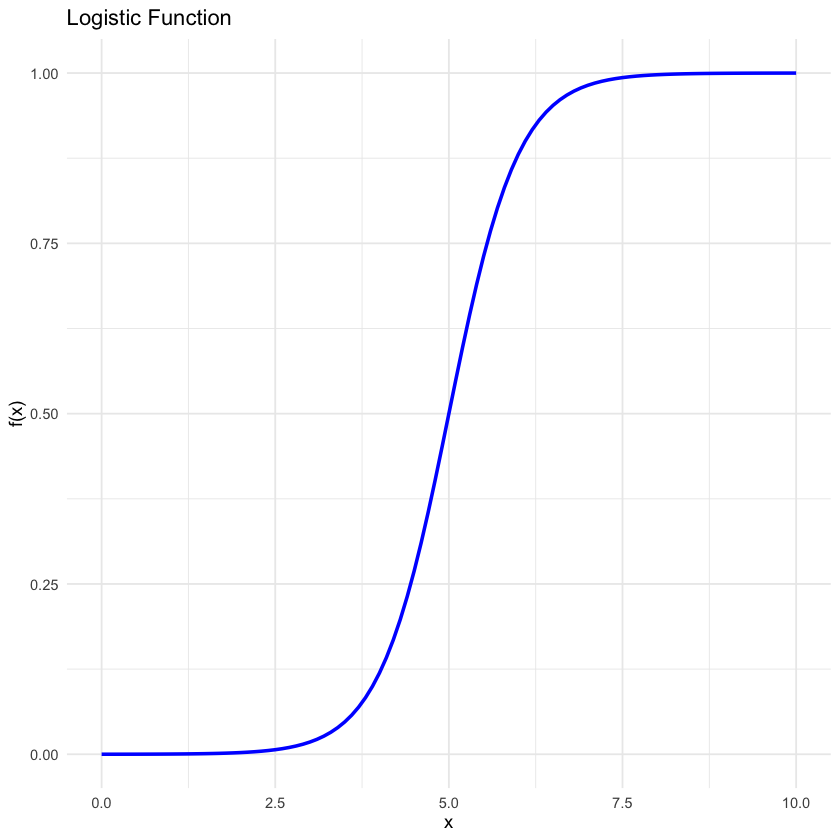

In [8]:
library(tidyverse)

# Parameters for the logistic function
niveau <- 1
rate <- 2
inflection <- 5

x <- seq(0, 10, by = 0.1)
# Logistic function
logistic_function <- function(x, niveau, rate, inflection) {
  niveau / (1 + exp(-rate * (x - inflection)))
}

# Calculate the logistic function values
y <- logistic_function(x, niveau, rate, inflection)

# Create a data frame for plotting
tbl <- tibble(
    x = x,
    y = y
)

# Plot the logistic function
ggplot(tbl, aes(x = x, y = y)) +
  geom_line(color = "blue", size = 1) +
  labs(title = "Logistic Function",
       x = "x",
       y = "f(x)") +
  theme_minimal()

In [9]:


# Keep only the left third of the data for fitting and add an error term
tbl <- tbl |>
  mutate(
    err = rnorm(nrow(tbl), mean = 0, sd = 0.05),
    y = y + err
  )

tbl_half <- tbl |>
  slice_head(n = nrow(tbl) %/% 2)

# Starting values estimated from the truncated data only.
# The self-start of SSlogis fails here (singular gradient), so we provide our own:
# left of the inflection point the curve is roughly exponential, so the slope of log(y) estimates the rate
slope <- coef(lm(log(y) ~ x, data = tbl_half))[["x"]]
start <- list(
    Asym = 2 * max(tbl_half$y),
    xmid = max(tbl_half$x),
    scal = 1 / slope
)

# Fit a logistic curve to the remaining data
# scaleOffset is needed because the data is noise-free (zero residuals)
fit <- nls(y ~ SSlogis(x, Asym, xmid, scal),
           data = tbl_half,
           start = start,
           control = nls.control(scaleOffset = 1))

# Compare the fitted parameters with the true ones
tibble(
    parameter = c("niveau", "inflection", "rate"),
    true = c(niveau, inflection, rate),
    fitted = c(coef(fit)[["Asym"]], coef(fit)[["xmid"]], 1 / coef(fit)[["scal"]])
)

# Plot the full curve, the data used for the fit and the fitted curve
tbl |>
  mutate(y_fit = predict(fit, newdata = tbl)) |>
  ggplot(aes(x = x)) +
  geom_line(aes(y = y), color = "blue", linewidth = 1) +
  geom_line(aes(y = y_fit), color = "red", linetype = "dashed", linewidth = 1) +
  geom_point(data = tbl_half, aes(y = y), size = 0.8) +
  labs(title = "SSlogis fit on the left half of the data",
       x = "x",
       y = "f(x)") +
  theme_minimal()

Warning message in log(y):
“NaNs produced”


ERROR: Error in nls(y ~ SSlogis(x, Asym, xmid, scal), data = tbl_half, start = start, : singular gradient
